# Insight 177 neural-network replication

Implements the published target and loss equations. See [alignment notes](../NN_PAPER_ALIGNMENT.md) for exact formulas, tests, and unresolved author conventions. Re-run all cells after source changes; old output files may be stale.


In [22]:
from pathlib import Path
import sys
import importlib
import pandas as pd
import matplotlib.pyplot as plt

# Locate the package from either the repository root or notebook directory.
PROJECT_ROOT = next(
    candidate
    for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
    for candidate in (parent, parent / 'paper_replication')
    if (candidate / 'src' / 'paper_replication' / 'config.py').is_file()
)
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import paper_replication
import paper_replication.config as config_module
import paper_replication.data as data_module
import paper_replication.evaluate as evaluate_module
import paper_replication.model as model_module
importlib.reload(config_module)
importlib.reload(model_module)
importlib.reload(data_module)
evaluate_module = importlib.reload(evaluate_module)
importlib.reload(paper_replication)
from paper_replication.config import ReplicationConfig, MARKETS
run_replication = evaluate_module.run_replication

DATA_DIR = PROJECT_ROOT / 'data_required'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'neural_network').mkdir(parents=True, exist_ok=True)
print(PROJECT_ROOT)

/mnt/c/Users/Julien/Desktop/Capstone Project/paper_replication


## Configuration

`futures_only` is the default Managed Money basis. Change it to `combined` only for a sensitivity run. The first rolling fit uses 1,024 full-batch epochs; later windows warm-start from the previous fit and use 36 epochs.

In [23]:
config = ReplicationConfig(data_dir=DATA_DIR, basis='futures_only', train_weeks=104, seed=7)
config

ReplicationConfig(data_dir=PosixPath('/mnt/c/Users/Julien/Desktop/Capstone Project/paper_replication/data_required'), basis='futures_only', train_weeks=104, hidden_factors=3, first_epochs=1024, rolling_epochs=36, learning_rate=0.01, adam_beta1=0.9, adam_beta2=0.999, adam_epsilon=1e-07, lambda_w=0.04, lambda_bias=0.01, evaluation_start='2015-01-01', evaluation_end='2025-12-31', seed=7, expanded=False)

## Paper-comparable run

This run retains the two-year warm-up and evaluates forecasts from 2015 through 2025.

In [24]:
paper_run = run_replication(config, expanded=False, progress=True)
paper_metrics = paper_run['metrics']
paper_metrics

Paper replication: 100%|██████████| 816/816 [02:43<00:00,  4.99week/s]  


r2_oos                     0.450318
directional_accuracy       0.718351
observations            3444.000000
dtype: float64

In [25]:
paper_predictions = paper_run['predictions']
paper_predictions.to_csv(OUTPUT_DIR / 'neural_network' / 'model_predictions_paper_window.csv', index=False)
try:
    paper_run['weekly_panel'].to_parquet(OUTPUT_DIR / 'neural_network' / 'weekly_features_paper_window.parquet', index=False)
except Exception as parquet_error:
    paper_run['weekly_panel'].to_csv(OUTPUT_DIR / 'neural_network' / 'weekly_features_paper_window.csv', index=False)
    print(f'Parquet export unavailable ({type(parquet_error).__name__}); saved the weekly panel as CSV instead.')
paper_metrics.to_csv(OUTPUT_DIR / 'neural_network' / 'metrics_paper_window.csv')
paper_predictions.head()

,market,report_week_tuesday,report_date,panel_date,actual_position,mm_mean_lag,mm_std_lag,actual_change,previous_report_week,predicted_y,y,predicted_position,previous_predicted_y,predicted_change
1,BRENT,2015-01-06,2015-01-06,2015-01-06,142286.0,122929.941176,56842.447972,23266.0,2014-12-30,-0.241455,0.340521,109205.043460,-0.216067,-1443.143310
7,BRENT,2015-01-13,2015-01-13,2015-01-13,142751.0,124089.137255,56170.557746,465.0,2015-01-06,-0.109936,0.332236,117913.964183,-0.028575,-4570.115947
13,BRENT,2015-01-20,2015-01-20,2015-01-20,127801.0,125132.843137,55659.941495,-14950.0,2015-01-13,-0.167616,0.047937,115803.359113,-0.284948,6530.684599
19,BRENT,2015-01-27,2015-01-27,2015-01-27,129740.0,125710.450980,55283.167567,1939.0,2015-01-20,-0.348270,0.072889,106456.985561,-0.394125,2535.012154
25,BRENT,2015-02-03,2015-02-03,2015-02-03,124499.0,126559.803922,54718.663888,-5241.0,2015-01-27,0.248996,-0.037662,140184.520369,0.108413,7692.516023


In [26]:
# Explicit coverage and cumulative paper comparison.
p = paper_run['predictions']
display(p.groupby('market')['report_week_tuesday'].agg(['min', 'max', 'count']))
display(pd.DataFrame({
    'replicated': paper_run['metrics'][['r2_oos', 'directional_accuracy']],
    'paper': pd.Series({'r2_oos': 0.4459, 'directional_accuracy': 0.7250}),
}).assign(difference_pp=lambda d: 100 * (d['replicated'] - d['paper'])))
assert p[['actual_change', 'predicted_change']].notna().all().all()


,min,max,count
market,,,
BRENT,2015-01-06,2025-12-30,574
GASOIL,2015-01-06,2025-12-30,574
HEATOIL,2015-01-06,2025-12-30,574
NATGAS,2015-01-06,2025-12-30,574
RBOB,2015-01-06,2025-12-30,574
WTI,2015-01-06,2025-12-30,574


,replicated,paper,difference_pp
r2_oos,0.450318,0.4459,0.441785
directional_accuracy,0.718351,0.7250,-0.664925


## Expanded-history run

This run uses all available weekly dates after the same 104-week warm-up. Its metrics should not be compared directly with the published tables unless the date range is restricted.

In [27]:
expanded_run = run_replication(config, expanded=True, progress=True)
expanded_metrics = expanded_run['metrics']
expanded_metrics

Expanded replication: 100%|██████████| 816/816 [02:52<00:00,  4.72week/s]  


r2_oos                     0.452137
directional_accuracy       0.712766
observations            3666.000000
dtype: float64

In [28]:
expanded_predictions = expanded_run['predictions']
expanded_predictions.to_csv(OUTPUT_DIR / 'neural_network' / 'model_predictions_expanded.csv', index=False)
try:
    expanded_run['weekly_panel'].to_parquet(OUTPUT_DIR / 'neural_network' / 'weekly_features_expanded.parquet', index=False)
except BaseException as parquet_error:
    expanded_run['weekly_panel'].to_csv(OUTPUT_DIR / 'neural_network' / 'weekly_features_expanded.csv', index=False)
    print(f'Parquet export unavailable ({type(parquet_error).__name__}); saved the weekly panel as CSV instead.')
expanded_metrics.to_csv(OUTPUT_DIR / 'neural_network' / 'metrics_expanded.csv')
expanded_predictions.tail()

,market,report_week_tuesday,report_date,panel_date,actual_position,mm_mean_lag,mm_std_lag,actual_change,previous_report_week,predicted_y,y,predicted_position,previous_predicted_y,predicted_change
3636,WTI,2026-07-28,2026-07-28,2026-07-28,92943.0,48315.698113,70710.684264,28964.0,2026-07-21,0.439875,0.631125,79419.539753,0.453598,-970.408091
3642,WTI,2026-08-04,2026-08-04,2026-08-04,86958.0,48215.811321,70756.478299,-5985.0,2026-07-28,0.427547,0.547543,78467.550878,0.500145,-5136.756345
3648,WTI,2026-08-11,2026-08-11,2026-08-11,79916.0,48019.037736,70753.394472,-7042.0,2026-08-04,0.612841,0.450819,91379.585734,0.480440,9367.821550
3654,WTI,2026-08-18,2026-08-18,2026-08-18,87479.0,47992.226415,70508.943169,7563.0,2026-08-11,0.675878,0.560025,95647.690098,0.542390,9412.110374
3660,WTI,2026-08-25,2026-08-25,2026-08-25,84020.0,48720.792453,69766.091882,-3459.0,2026-08-18,0.667930,0.505965,95319.642057,0.643146,1729.064020


## Diagnostics

The plot compares actual and model-predicted normalized Managed Money positions by market. The paper's published figures use position changes for scoring; this plot is a visual diagnostic for level comovement.

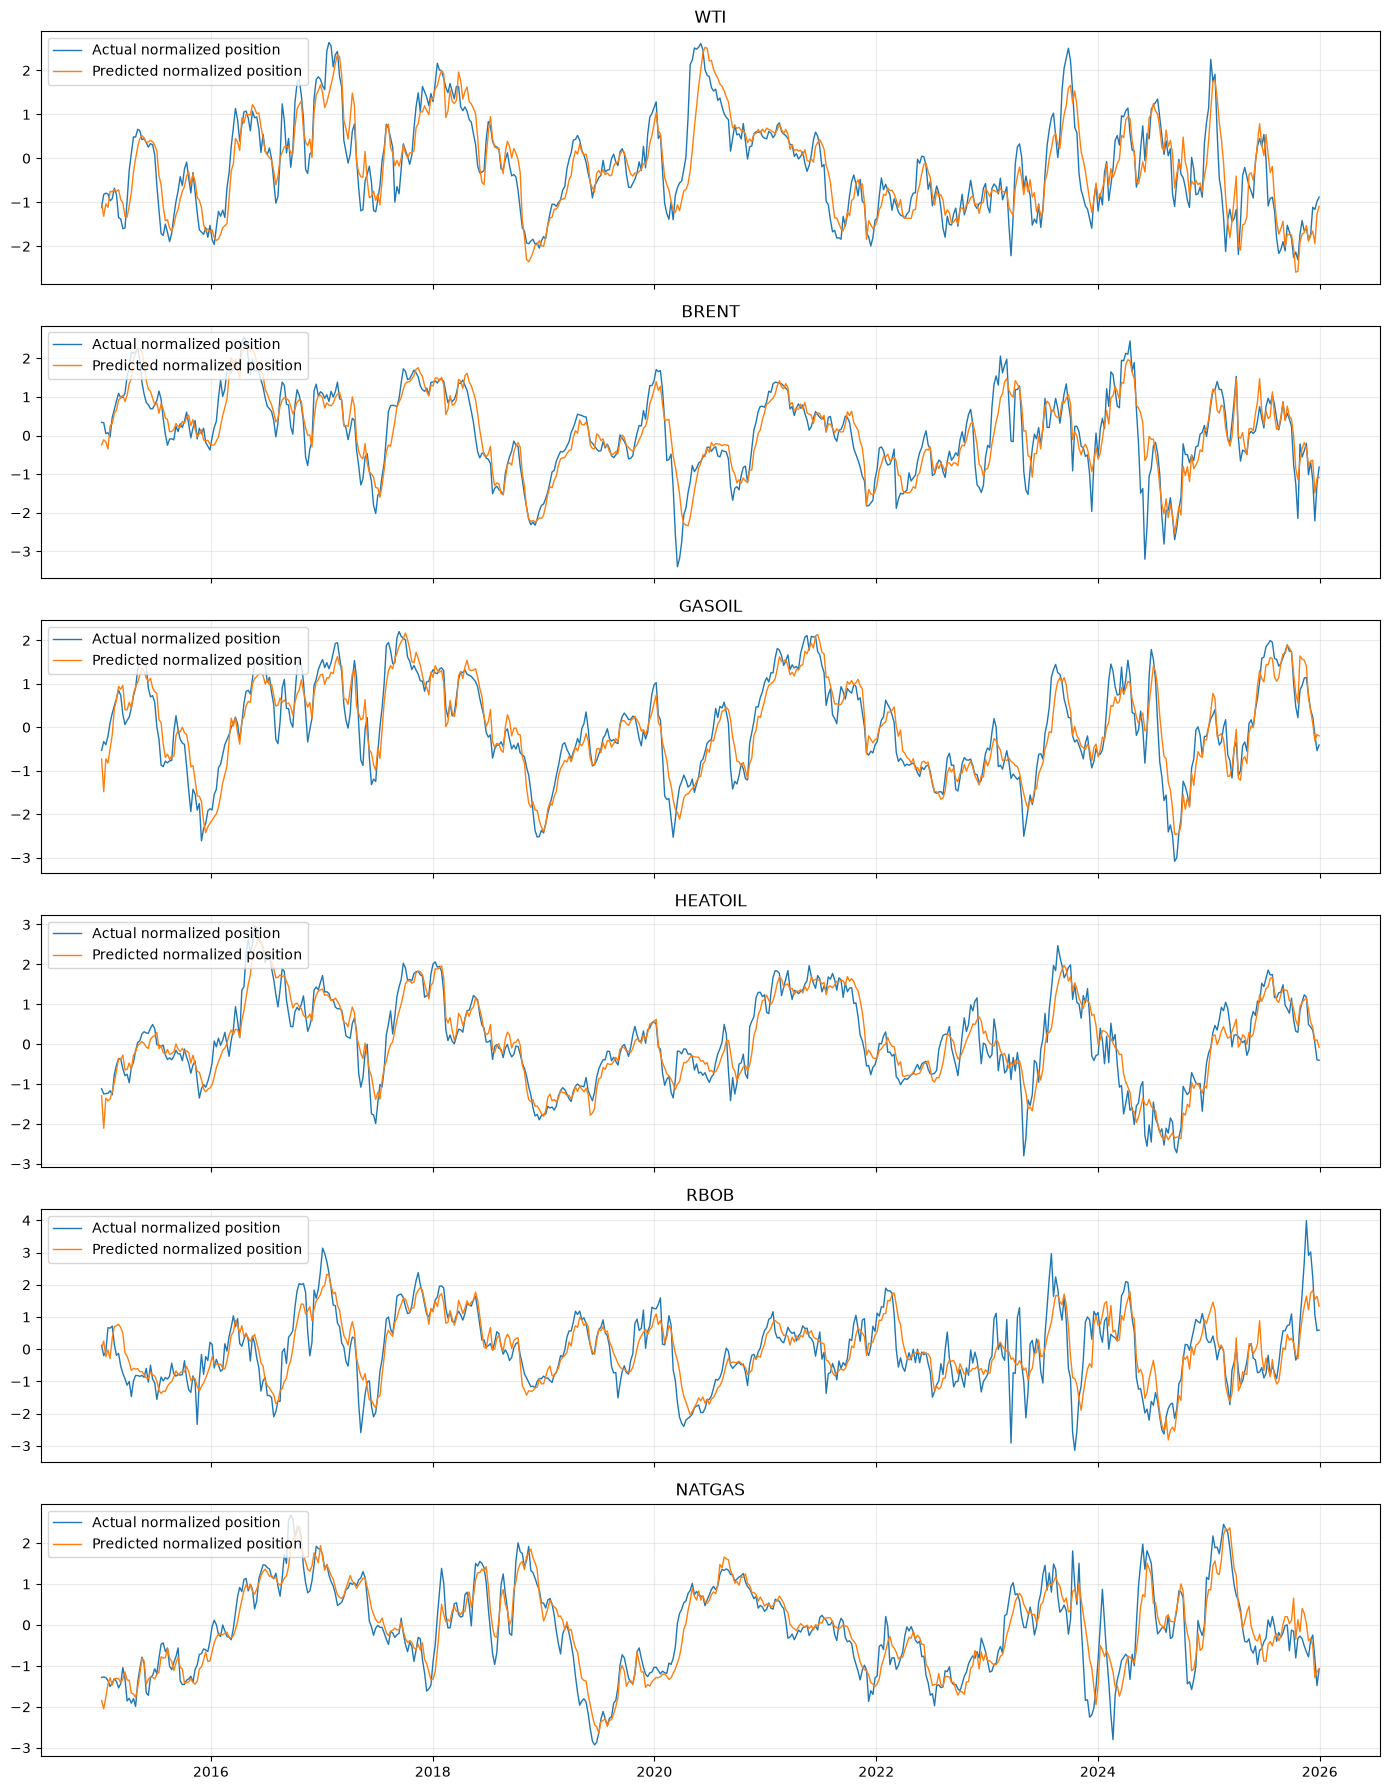

In [29]:
fig, axes = plt.subplots(len(MARKETS), 1, figsize=(14, 18), sharex=True)
for axis, market in zip(axes, MARKETS):
    subset = paper_predictions.loc[paper_predictions['market'].eq(market)]
    axis.plot(subset['report_week_tuesday'], subset['y'], label='Actual normalized position', linewidth=1)
    axis.plot(subset['report_week_tuesday'], subset['predicted_y'], label='Predicted normalized position', linewidth=1)
    axis.set_title(market)
    axis.grid(alpha=0.25)
    axis.legend(loc='upper left')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'neural_network' / 'figures_model_vs_actual_levels.png', dpi=160)
plt.show()

## Checks to record

Compare the paper-window metrics with Insight 177's reported cumulative performance. Differences can arise from the source data vintage, futures roll reconstruction, futures-only versus combined COT basis, missing-settlement handling, and exact implementation details of the regularized bias. Keep the expanded-history results separate from the paper-comparable results.

In [30]:
# Fallback export for environments where pandas/pyarrow versions are incompatible.
expanded_predictions.to_csv(OUTPUT_DIR / 'neural_network' / 'model_predictions_expanded.csv', index=False)
expanded_run['weekly_panel'].to_csv(OUTPUT_DIR / 'neural_network' / 'weekly_features_expanded.csv', index=False)
expanded_metrics.to_csv(OUTPUT_DIR / 'neural_network' / 'metrics_expanded.csv')
print('Saved expanded predictions, weekly panel, and metrics as CSV files.')

Saved expanded predictions, weekly panel, and metrics as CSV files.


## Final comparison with Insight 177 (Tables 1 and 2)

Compare the **Our Model** panels in the [paper](../../Insight-177-Money-Positioning-in-Energy.pdf), pages 9–10, with the neural network's **2015–2025 paper run**. Expanded-run results are excluded.

R² uses `1 − sum(error²) / sum(actual_change²)`; directional accuracy is the fraction of matching signs. All-market results pool observations, rather than average market scores. Differences are **ours minus paper, in percentage points**. Published figures are rounded to two decimals. Year assignment uses the panel's report as-of date, including holiday adjustments.


In [31]:
import numpy as np
from IPython.display import display

comparison_markets = ['BRENT', 'WTI', 'GASOIL', 'HEATOIL', 'RBOB', 'NATGAS']
comparison_labels = ['ICE Brent', 'CME WTI', 'ICE Gasoil', 'CME Heating Oil',
                     'CME RBOB Gasoline', 'CME Natural Gas', 'ALL Markets']
comparison_periods = list(range(2015, 2026)) + ['Cumulative']

# Transcribed from the Our Model panels, not the Simple Linear Regression panels.
paper_nn_r2 = pd.DataFrame([
    [25.13,40.91,30.33,15.91,-4.86,29.38,30.39],
    [53.19,64.70,48.03,34.55,29.43,32.01,51.44],
    [47.79,46.59,51.00,43.66,57.34,56.80,49.56],
    [22.46,14.95,46.06,59.99,54.57,62.42,40.02],
    [40.07,34.91,53.92,38.70,38.02,59.10,45.21],
    [20.22,41.53,42.46,29.95,33.62,17.60,26.72],
    [54.33,33.54,42.72,7.70,26.87,35.52,40.79],
    [26.68,36.60,19.62,-10.40,16.66,28.93,28.10],
    [53.87,48.06,20.49,16.15,27.01,44.28,47.99],
    [58.85,46.76,63.26,40.16,10.97,53.87,54.37],
    [69.28,24.19,39.89,18.26,33.93,11.01,49.96],
    [48.34,41.86,45.76,33.74,33.99,43.69,44.59],
], index=comparison_periods, columns=comparison_labels)
paper_nn_accuracy = pd.DataFrame([
    [65.38,75.00,75.00,71.15,63.46,73.08,70.51],
    [78.85,80.77,76.92,63.46,55.77,80.77,72.76],
    [73.08,73.08,67.31,61.54,80.77,84.62,73.40],
    [66.04,67.92,73.58,86.79,83.02,75.47,75.47],
    [73.08,76.92,80.77,86.54,75.00,84.62,79.49],
    [67.31,67.31,75.00,65.38,67.31,59.62,66.99],
    [78.85,78.85,63.46,53.85,63.46,71.15,68.27],
    [71.15,76.92,67.31,65.38,61.54,67.31,68.27],
    [71.15,80.77,78.85,59.62,67.31,71.15,71.47],
    [83.02,83.02,81.13,71.70,71.70,79.25,78.30],
    [86.54,75.00,73.08,63.46,76.92,59.62,72.44],
    [74.04,75.96,73.87,68.12,69.69,73.34,72.50],
], index=comparison_periods, columns=comparison_labels)


In [32]:
comparison_predictions = paper_run['predictions'].copy()
comparison_predictions['panel_date'] = pd.to_datetime(comparison_predictions['panel_date'])
comparison_predictions = comparison_predictions.loc[
    comparison_predictions['panel_date'].between('2015-01-01', '2025-12-31')].copy()
if comparison_predictions.empty:
    raise ValueError('Run the paper-window model before comparing results.')
if not np.isfinite(comparison_predictions[['actual_change', 'predicted_change']].to_numpy()).all():
    raise ValueError('Non-finite predictions: rerun the corrected paper-window model.')
if comparison_predictions.duplicated(['market', 'report_week_tuesday']).any():
    raise ValueError('Duplicate market/week predictions.')
comparison_predictions['year'] = comparison_predictions['panel_date'].dt.year


def nn_comparison_metric(frame, metric):
    if frame.empty:
        return np.nan
    actual = frame['actual_change'].to_numpy()
    predicted = frame['predicted_change'].to_numpy()
    if metric == 'r2':
        denominator = np.sum(actual ** 2)
        return 100 * (1 - np.sum((actual - predicted) ** 2) / denominator) if denominator else np.nan
    return 100 * np.mean(np.sign(actual) == np.sign(predicted))


def nn_comparison_table(metric):
    rows = []
    for period in comparison_periods:
        subset = comparison_predictions if period == 'Cumulative' else comparison_predictions.loc[
            comparison_predictions['year'].eq(period)]
        rows.append([nn_comparison_metric(subset.loc[subset['market'].eq(m)], metric)
                     for m in comparison_markets] + [nn_comparison_metric(subset, metric)])
    return pd.DataFrame(rows, index=comparison_periods, columns=comparison_labels)

nn_r2 = nn_comparison_table('r2')
nn_accuracy = nn_comparison_table('accuracy')
nn_r2_gap = nn_r2 - paper_nn_r2
nn_accuracy_gap = nn_accuracy - paper_nn_accuracy

coverage = comparison_predictions.groupby('market').agg(
    first_date=('panel_date', 'min'), last_date=('panel_date', 'max'), observations=('panel_date', 'size'))
display(coverage.reindex(comparison_markets))
if len(comparison_predictions) != 3444 or not coverage.reindex(comparison_markets)['observations'].eq(574).all():
    print('Incomplete or different coverage: the published sample has 574 weeks per market. Interpret comparisons accordingly.')

cumulative_comparison = pd.DataFrame({
    'R² ours (%)': nn_r2.loc['Cumulative'],
    'R² paper (%)': paper_nn_r2.loc['Cumulative'],
    'R² difference (pp)': nn_r2_gap.loc['Cumulative'],
    'Accuracy ours (%)': nn_accuracy.loc['Cumulative'],
    'Accuracy paper (%)': paper_nn_accuracy.loc['Cumulative'],
    'Accuracy difference (pp)': nn_accuracy_gap.loc['Cumulative'],
})
print('Cumulative results, 2015–2025')
display(cumulative_comparison.style.format('{:.2f}'))


,first_date,last_date,observations
market,,,
BRENT,2015-01-06,2025-12-30,574
WTI,2015-01-06,2025-12-30,574
GASOIL,2015-01-06,2025-12-30,574
HEATOIL,2015-01-06,2025-12-30,574
RBOB,2015-01-06,2025-12-30,574
NATGAS,2015-01-06,2025-12-30,574


Cumulative results, 2015–2025


,R² ours (%),R² paper (%),R² difference (pp),Accuracy ours (%),Accuracy paper (%),Accuracy difference (pp)
ICE Brent,49.17,48.34,0.83,73.52,74.04,-0.52
CME WTI,42.03,41.86,0.17,74.39,75.96,-1.57
ICE Gasoil,46.75,45.76,0.99,73.87,73.87,-0.00
CME Heating Oil,36.38,33.74,2.64,67.94,68.12,-0.18
CME RBOB Gasoline,27.71,33.99,-6.28,68.82,69.69,-0.87
CME Natural Gas,44.21,43.69,0.52,72.47,73.34,-0.87
ALL Markets,45.03,44.59,0.44,71.84,72.50,-0.66


Table 1 — R² by year and market (%)


Table 2 — Directional accuracy by year and market (%)


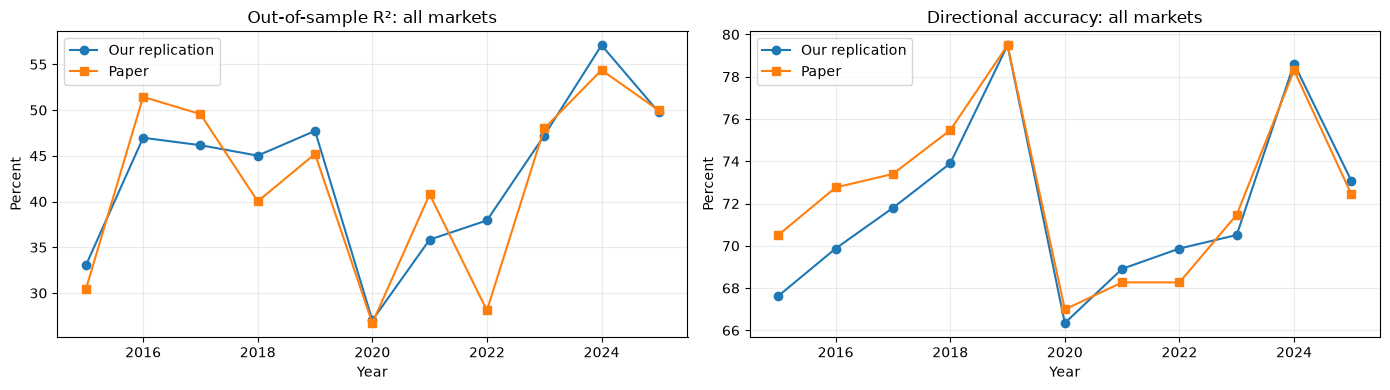

Comparison tables and chart saved to /mnt/c/Users/Julien/Desktop/Capstone Project/paper_replication/outputs/neural_network


In [33]:
print('Table 1 — R² by year and market (%)')
nn_r2_comparison = pd.concat({'Ours': nn_r2, 'Paper': paper_nn_r2, 'Difference (pp)': nn_r2_gap}, axis=1)
display(nn_r2_comparison.style.format('{:.2f}', na_rep='Missing'))
print('Table 2 — Directional accuracy by year and market (%)')
nn_accuracy_comparison = pd.concat({'Ours': nn_accuracy, 'Paper': paper_nn_accuracy,
                                   'Difference (pp)': nn_accuracy_gap}, axis=1)
display(nn_accuracy_comparison.style.format('{:.2f}', na_rep='Missing'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, ours, paper, title in zip(axes, [nn_r2, nn_accuracy],
                                 [paper_nn_r2, paper_nn_accuracy], ['Out-of-sample R²', 'Directional accuracy']):
    ax.plot(range(2015, 2026), ours.loc[2015:2025, 'ALL Markets'], marker='o', label='Our replication')
    ax.plot(range(2015, 2026), paper.loc[2015:2025, 'ALL Markets'], marker='s', label='Paper')
    ax.set(title=f'{title}: all markets', xlabel='Year', ylabel='Percent')
    ax.grid(alpha=.25)
    ax.legend()
fig.tight_layout()
plt.show()

comparison_dir = OUTPUT_DIR / 'neural_network'
comparison_dir.mkdir(parents=True, exist_ok=True)
cumulative_comparison.to_csv(comparison_dir / 'cumulative_vs_paper.csv')
nn_r2_comparison.to_csv(comparison_dir / 'r2_oos_vs_paper.csv')
nn_accuracy_comparison.to_csv(comparison_dir / 'directional_accuracy_vs_paper.csv')
fig.savefig(comparison_dir / 'annual_vs_paper.png', dpi=160, bbox_inches='tight')
print(f'Comparison tables and chart saved to {comparison_dir}')
